In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df=pd.read_csv('State_wise_Health_income.csv')
df

,Unnamed: 0,States,Health_indices1,Health_indices2,Per_capita_income,GDP
0,0,Bachevo,417,66,564,1823
1,1,Balgarchevo,1485,646,2710,73662
2,2,Belasitsa,654,299,1104,27318
3,3,Belo_Pole,192,25,573,250
4,4,Beslen,43,8,528,22
...,...,...,...,...,...,...
291,291,Greencastle,3443,970,2499,238636
292,292,Greenisland,2963,793,1257,162831
293,293,Greyabbey,3276,609,1522,120184
294,294,Greysteel,3463,847,934,199403


In [3]:
df.drop(columns='Unnamed: 0',inplace=True)

In [15]:
df

,States,Health_indices1,Health_indices2,Per_capita_income,GDP
0,Bachevo,417,66,564,1823
1,Balgarchevo,1485,646,2710,73662
2,Belasitsa,654,299,1104,27318
3,Belo_Pole,192,25,573,250
4,Beslen,43,8,528,22
...,...,...,...,...,...
291,Greencastle,3443,970,2499,238636
292,Greenisland,2963,793,1257,162831
293,Greyabbey,3276,609,1522,120184
294,Greysteel,3463,847,934,199403


### In CLustering we need the numerical data to calculate the euclidean distace so we can drop the state colimn here and use it afterwards

In [4]:
df_1=df.drop('States',axis=1)
df_1

,Health_indices1,Health_indices2,Per_capita_income,GDP
0,417,66,564,1823
1,1485,646,2710,73662
2,654,299,1104,27318
3,192,25,573,250
4,43,8,528,22
...,...,...,...,...
291,3443,970,2499,238636
292,2963,793,1257,162831
293,3276,609,1522,120184
294,3463,847,934,199403


In [18]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Health_indices1    296 non-null    int64
 1   Health_indices2    296 non-null    int64
 2   Per_capita_income  296 non-null    int64
 3   GDP                296 non-null    int64
dtypes: int64(4)
memory usage: 9.4 KB


In [19]:
df.isnull().sum()

States               0
Health_indices1      0
Health_indices2      0
Per_capita_income    0
GDP                  0
dtype: int64

In [23]:
df_1.duplicated().sum()

np.int64(1)

In [24]:
df_1.describe()

,Health_indices1,Health_indices2,Per_capita_income,GDP
count,296.000000,296.000000,296.000000,296.000000
mean,2629.195946,693.594595,2159.597973,174717.050676
std,2041.890970,469.738035,1493.663013,167439.128587
min,-10.000000,0.000000,500.000000,22.000000
25%,640.000000,173.500000,746.000000,8679.500000
50%,2446.500000,810.500000,1869.000000,135748.500000
75%,4102.750000,1076.000000,3138.750000,314751.250000
max,10219.000000,1508.000000,7049.000000,728575.000000


## Feature Scaling is important in Clustering as it is distance based algorithm 

    StandardScaler approach
    Zscore approach
    both are same just zscore is easy to write

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_scaled=pd.DataFrame(scaler.fit_transform(df_1),columns=df_1.columns)
df_scaled

,Health_indices1,Health_indices2,Per_capita_income,GDP
0,-1.085240,-1.338315,-1.070054,-1.034327
1,-0.561310,-0.101493,0.369115,-0.604555
2,-0.968975,-0.841454,-0.707914,-0.881805
3,-1.195619,-1.425745,-1.064018,-1.043738
4,-1.268714,-1.461997,-1.094197,-1.045102
...,...,...,...,...
291,0.399229,0.589421,0.227613,0.382391
292,0.163755,0.211977,-0.605308,-0.071108
293,0.317304,-0.180394,-0.427592,-0.326240
294,0.409040,0.327130,-0.821921,0.147682


### Zscore
    from scipy.stats import zscore
    df_scaled=df_1.apply(zscore)
    df_scaled

### Building Cluster
    Heirarchial Cluster

In [24]:
import scipy.cluster.hierarchy as sch

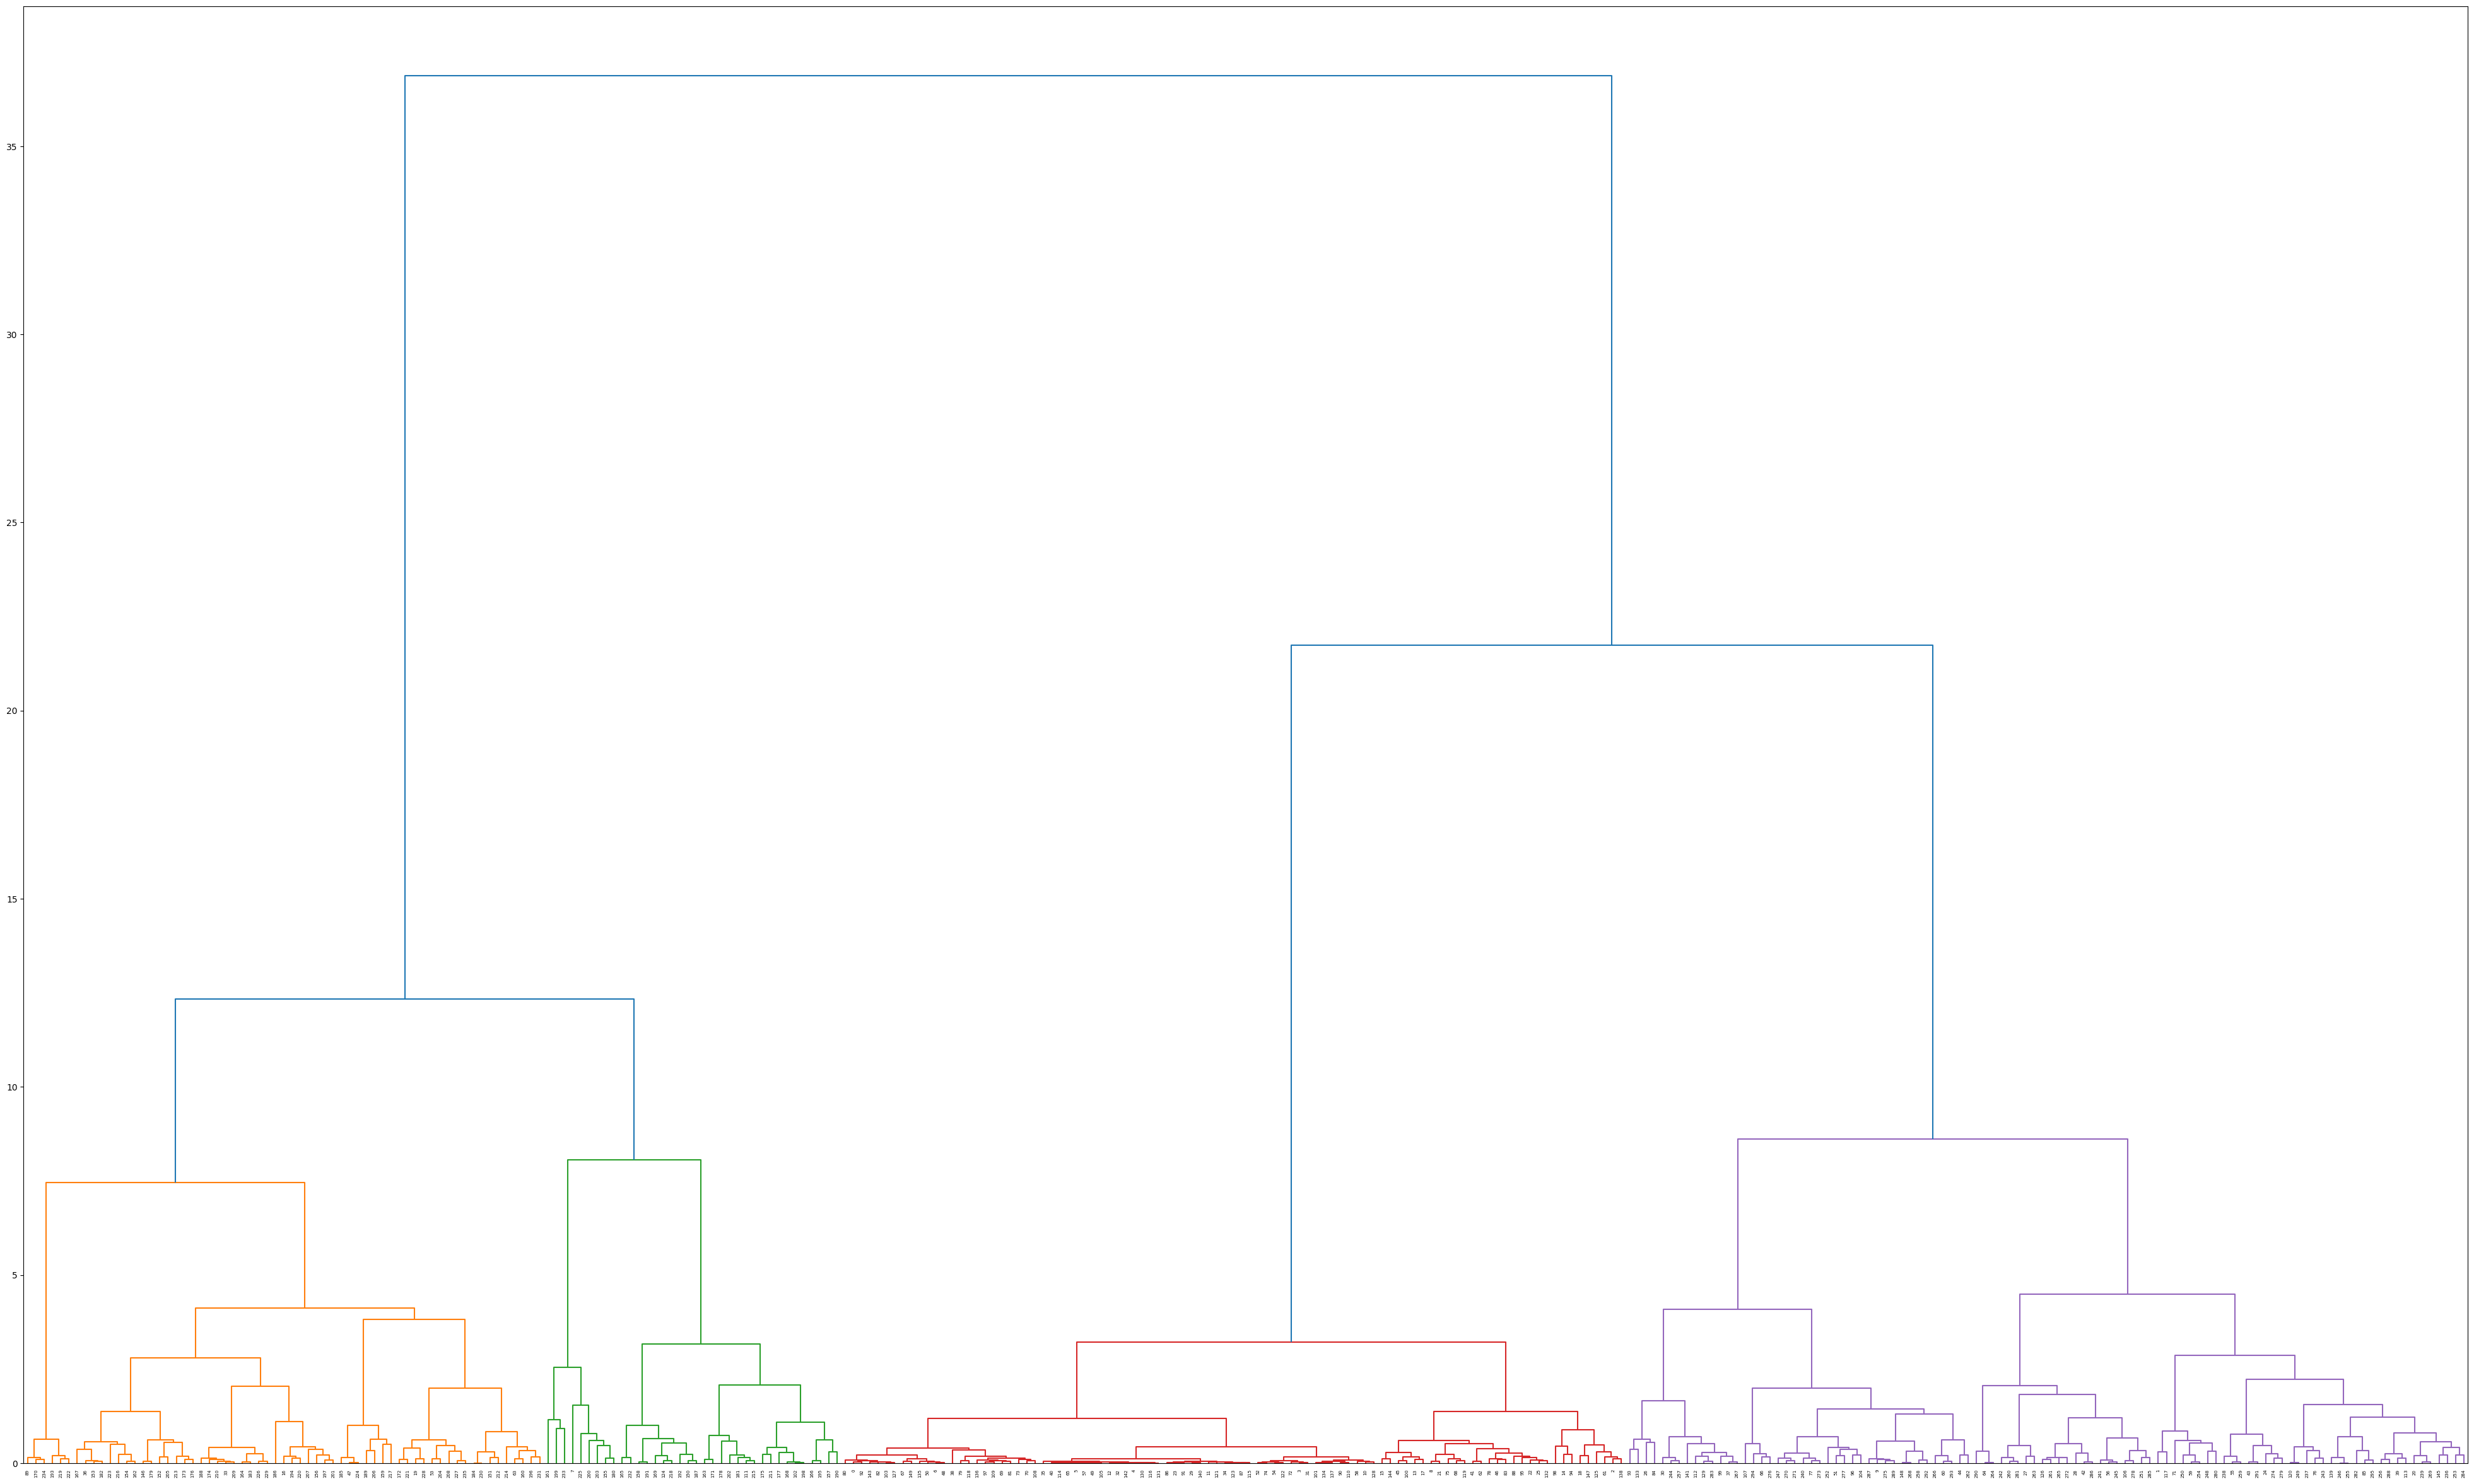

In [39]:
plt.figure(figsize=(50,30))
sch.dendrogram(sch.linkage(df_scaled,method='ward'),color_threshold=10)
plt.show()

In [25]:
### Method1: Cluster=4
cluster_1=sch.fcluster(sch.linkage(df_scaled,method='ward'),4,criterion='maxclust')   # 4 means 4 cluster
cluster_1

array([3, 4, 3, 3, 3, 3, 3, 2, 3, 4, 3, 3, 3, 3, 3, 3, 1, 3, 3, 1, 4, 3,
       3, 3, 4, 3, 4, 4, 4, 3, 4, 3, 3, 1, 3, 3, 1, 4, 3, 4, 3, 3, 4, 4,
       4, 3, 3, 1, 3, 3, 3, 4, 3, 1, 3, 4, 4, 3, 3, 4, 4, 3, 3, 1, 4, 3,
       4, 3, 3, 3, 3, 4, 3, 3, 3, 3, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3,
       3, 1, 3, 3, 3, 4, 3, 3, 4, 3, 3, 4, 3, 3, 2, 3, 4, 3, 4, 4, 3, 3,
       3, 2, 4, 4, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 2, 3, 4, 3, 3, 4, 3, 3,
       3, 4, 3, 3, 3, 3, 3, 4, 3, 4, 3, 3, 3, 4, 1, 3, 4, 3, 2, 1, 1, 1,
       1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2,
       1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1,
       2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)

In [42]:
cluster_2=sch.fcluster(sch.linkage(df_scaled,method='ward'),10,criterion='maxclust')   # 10 means 10 cluster
cluster_2

array([ 6, 10,  6,  6,  6,  6,  6,  4,  6,  8,  6,  6,  6,  6,  6,  6,  2,
        6,  6,  3, 10,  6,  6,  6, 10,  6,  7,  9,  9,  6,  7,  6,  6,  2,
        6,  6,  2,  7,  6, 10,  6,  6,  9, 10,  8,  6,  6,  3,  6,  6,  6,
        8,  6,  3,  6, 10,  9,  6,  6, 10,  8,  6,  6,  3,  9,  6,  8,  6,
        6,  6,  6, 10,  6,  6,  6,  6, 10,  8,  6,  6,  6,  6,  6,  6,  7,
       10,  6,  6,  6,  1,  6,  6,  6,  7,  6,  6,  8,  6,  6,  7,  6,  6,
        5,  6,  8,  6,  9,  8,  6,  6,  6,  5,  7, 10,  6,  6,  6, 10,  6,
        6, 10,  6,  6,  6,  5,  6,  9,  6,  6,  7,  6,  6,  6,  7,  6,  6,
        6,  6,  6, 10,  6,  7,  6,  6,  6, 10,  2,  6,  8,  6,  5,  3,  2,
        2,  2,  4,  2,  5,  5,  3,  3,  4,  2,  5,  2,  5,  5,  2,  5,  5,
        1,  5,  3,  2,  2,  5,  2,  5,  5,  2,  4,  5,  2,  2,  3,  3,  2,
        5,  2,  3,  5,  5,  5,  1,  2,  5,  3,  2,  5,  4,  4,  2,  5,  4,
        3,  2,  3,  2,  3,  2,  2,  5,  3,  2,  3,  5,  2,  3,  5,  1,  2,
        3,  1,  2,  3,  4

In [48]:
### Method2: Cluster=10
cluster_3=sch.fcluster(sch.linkage(df_scaled,method='ward'),10,criterion='distance')
cluster_3
# Here 10 is the value of color threshod in dendogram, in dendogram there are only 4 colours therefore here only 4 clusters are formed even if u wrote 10

array([3, 4, 3, 3, 3, 3, 3, 2, 3, 4, 3, 3, 3, 3, 3, 3, 1, 3, 3, 1, 4, 3,
       3, 3, 4, 3, 4, 4, 4, 3, 4, 3, 3, 1, 3, 3, 1, 4, 3, 4, 3, 3, 4, 4,
       4, 3, 3, 1, 3, 3, 3, 4, 3, 1, 3, 4, 4, 3, 3, 4, 4, 3, 3, 1, 4, 3,
       4, 3, 3, 3, 3, 4, 3, 3, 3, 3, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3,
       3, 1, 3, 3, 3, 4, 3, 3, 4, 3, 3, 4, 3, 3, 2, 3, 4, 3, 4, 4, 3, 3,
       3, 2, 4, 4, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 2, 3, 4, 3, 3, 4, 3, 3,
       3, 4, 3, 3, 3, 3, 3, 4, 3, 4, 3, 3, 3, 4, 1, 3, 4, 3, 2, 1, 1, 1,
       1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2,
       1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1,
       2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)

In [26]:
df_1['Cluster_1']=cluster_1
df_1

,Health_indices1,Health_indices2,Per_capita_income,GDP,KMeans_cluster,Cluster_1
0,417,66,564,1823,2,3
1,1485,646,2710,73662,0,4
2,654,299,1104,27318,2,3
3,192,25,573,250,2,3
4,43,8,528,22,2,3
...,...,...,...,...,...,...
291,3443,970,2499,238636,0,4
292,2963,793,1257,162831,0,4
293,3276,609,1522,120184,0,4
294,3463,847,934,199403,0,4


In [56]:
info=df_1.groupby('Cluster_1').mean()

,Health_indices1,Health_indices2,Per_capita_income,GDP
Cluster_1,,,,
1,4796.174603,1129.936508,2419.746032,382809.936508
2,5146.444444,1327.138889,5047.083333,367196.916667
3,401.063158,104.536842,680.673684,5388.768421
4,2477.549020,749.117647,2357.235294,135962.735294


In [58]:
df_1['Cluster_1'].value_counts().sort_index()

Cluster_1
1     63
2     36
3     95
4    102
Name: count, dtype: int64

In [59]:
info=df_1.groupby('Cluster_1').mean()

In [60]:
info['Count']=df_1['Cluster_1'].value_counts().sort_index()

In [61]:
info

,Health_indices1,Health_indices2,Per_capita_income,GDP,Count
Cluster_1,,,,,
1,4796.174603,1129.936508,2419.746032,382809.936508,63
2,5146.444444,1327.138889,5047.083333,367196.916667,36
3,401.063158,104.536842,680.673684,5388.768421,95
4,2477.549020,749.117647,2357.235294,135962.735294,102


## Kmeans Clustering

In [18]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,random_state=1)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)    #centroid value distance b/w clusters

In [19]:
for i in range(2,11):
    print('The number of Clusters are ',i,' The Wcss value is ',wcss[i-2])

The number of Clusters are  2  The Wcss value is  467.5301969971571
The number of Clusters are  3  The Wcss value is  259.2278544455929
The number of Clusters are  4  The Wcss value is  182.55166363611207
The number of Clusters are  5  The Wcss value is  149.2981761554087
The number of Clusters are  6  The Wcss value is  116.90112256933318
The number of Clusters are  7  The Wcss value is  90.38643890433258
The number of Clusters are  8  The Wcss value is  80.40752440419958
The number of Clusters are  9  The Wcss value is  74.41538092742611
The number of Clusters are  10  The Wcss value is  65.73101590780507


## The Elbow Method

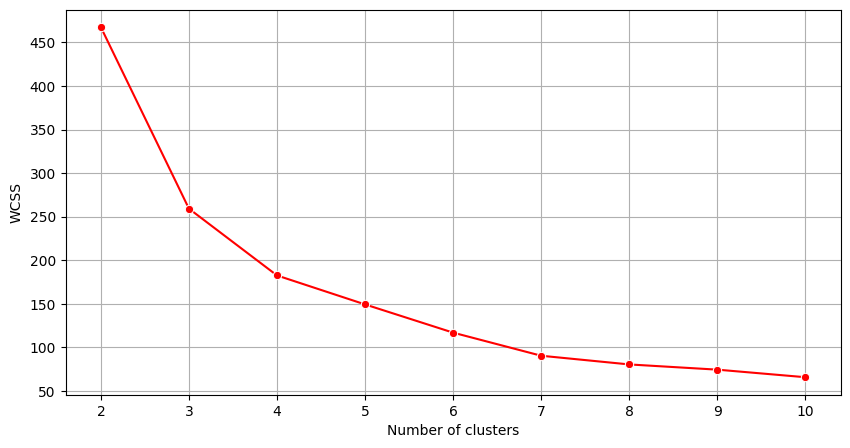

In [82]:
plt.figure(figsize=(10,5))
sns.lineplot(x=list(range(2,11)),y=wcss,color='red',marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()

##### Here u can check which K is good

In [21]:
kmeans=KMeans(n_clusters=4,random_state=2)
kmeans.fit(df_scaled)
clusters=kmeans.labels_
clusters

array([2, 0, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3, 0, 2,
       2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 3, 2, 2, 3, 0, 2, 0, 2, 2, 0, 0,
       0, 2, 2, 0, 2, 2, 2, 0, 2, 3, 2, 0, 0, 2, 2, 0, 0, 2, 2, 3, 0, 2,
       0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 3, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 1, 2, 0, 2, 0, 3, 2, 2,
       2, 1, 0, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 1, 2, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 3, 2, 0, 2, 1, 3, 3, 3,
       3, 1, 3, 1, 1, 3, 3, 1, 3, 1, 3, 1, 1, 3, 1, 1, 3, 1, 3, 3, 3, 1,
       3, 1, 1, 3, 1, 1, 3, 3, 3, 0, 3, 1, 3, 3, 1, 1, 1, 3, 3, 1, 3, 3,
       1, 1, 1, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 1, 3,
       3, 3, 3, 3, 0, 1, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [27]:
df_1['KMeans_cluster']=clusters
df_1

,Health_indices1,Health_indices2,Per_capita_income,GDP,KMeans_cluster,Cluster_1
0,417,66,564,1823,2,3
1,1485,646,2710,73662,0,4
2,654,299,1104,27318,2,3
3,192,25,573,250,2,3
4,43,8,528,22,2,3
...,...,...,...,...,...,...
291,3443,970,2499,238636,0,4
292,2963,793,1257,162831,0,4
293,3276,609,1522,120184,0,4
294,3463,847,934,199403,0,4


In [29]:
info=df_1.groupby(df_1['KMeans_cluster']).mean()
info

,Health_indices1,Health_indices2,Per_capita_income,GDP,Cluster_1
KMeans_cluster,,,,,
0,2560.316327,780.510204,2483.193878,139405.642857,3.908163
1,5146.444444,1327.138889,5047.083333,367196.916667,2.000000
2,499.158416,116.356436,693.772277,9428.099010,3.059406
3,4781.049180,1135.819672,2362.655738,391527.327869,1.049180


In [30]:
info['Counts']=df_1['KMeans_cluster'].value_counts().sort_index()
info

,Health_indices1,Health_indices2,Per_capita_income,GDP,Cluster_1,Counts
KMeans_cluster,,,,,,
0,2560.316327,780.510204,2483.193878,139405.642857,3.908163,98
1,5146.444444,1327.138889,5047.083333,367196.916667,2.000000,36
2,499.158416,116.356436,693.772277,9428.099010,3.059406,101
3,4781.049180,1135.819672,2362.655738,391527.327869,1.049180,61


### Now add clusters to OG dataset

In [36]:
df["Kmeans_cluster"]=clusters
df["Heirarchial_cluster"]=cluster_1
df

,States,Health_indices1,Health_indices2,Per_capita_income,GDP,Kmeans_cluster,Heirarchial_cluster
0,Bachevo,417,66,564,1823,2,3
1,Balgarchevo,1485,646,2710,73662,0,4
2,Belasitsa,654,299,1104,27318,2,3
3,Belo_Pole,192,25,573,250,2,3
4,Beslen,43,8,528,22,2,3
...,...,...,...,...,...,...,...
291,Greencastle,3443,970,2499,238636,0,4
292,Greenisland,2963,793,1257,162831,0,4
293,Greyabbey,3276,609,1522,120184,0,4
294,Greysteel,3463,847,934,199403,0,4


## now export the dataset
    df.to_csv('asdfghjk.csv')

# DBSCAN
    it has two param 
    1) epsilon: The radius of the cluster, outside this radius all other points are considered as outlier 
    2) min_sample= Min number of points inside the cluster, if a cluster has less than the min_sample and the distance of both clusters are not same as episilon, it is an outlier

In [38]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=0.5,min_samples=5)
db.fit(df_scaled)

DBSCAN()

In [39]:
dbclusters=db.labels_
dbclusters

array([ 0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  2,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  3, -1,
        0,  0, -1,  0,  0,  0,  1,  0,  0,  0,  0,  0, -1,  2,  0,  0,  2,
        0,  0,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  0,  1,  0,
        0,  1,  0,  3,  2

In [41]:
df_1['DB_cluster']=dbclusters

In [42]:
df_1

,Health_indices1,Health_indices2,Per_capita_income,GDP,KMeans_cluster,Cluster_1,DB_cluster
0,417,66,564,1823,2,3,0
1,1485,646,2710,73662,0,4,0
2,654,299,1104,27318,2,3,0
3,192,25,573,250,2,3,0
4,43,8,528,22,2,3,0
...,...,...,...,...,...,...,...
291,3443,970,2499,238636,0,4,0
292,2963,793,1257,162831,0,4,0
293,3276,609,1522,120184,0,4,0
294,3463,847,934,199403,0,4,0


In [44]:
df_1['DB_cluster'].value_counts()

DB_cluster
 0    270
-1     10
 1      6
 3      5
 2      5
Name: count, dtype: int64

##### These -1 are the outliers

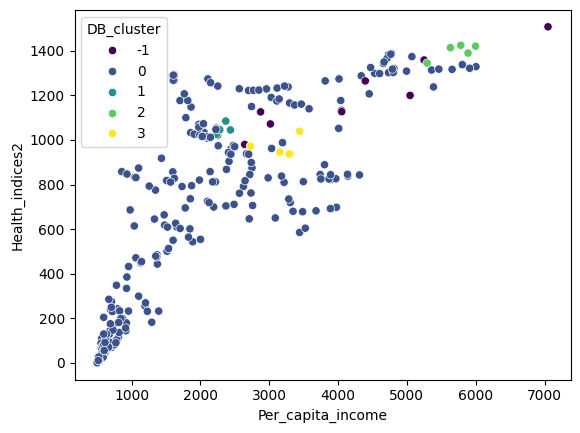

In [47]:
sns.scatterplot(x=df_1['Per_capita_income'],y=df['Health_indices2'],hue=df_1['DB_cluster'],palette='viridis')
plt.show()